**Fichier transaction**

In [120]:
import pandas as pd
df_transactions = pd.read_csv('/content/drive/MyDrive/projet9/Transactions.nettoyee.csv', sep=';')
df_transactions.head()

/tmp/ipykernel_3057/2920193055.py:2: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv('/content/drive/MyDrive/projet9/Transactions.nettoyee.csv', sep=';')


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [121]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [122]:
df_transactions.isnull().sum()

,0
id_prod,361041
date,361041
session_id,361041
client_id,361041


In [123]:
# verifier pour chaque ligne, si toutes les colonnes sont nulles
df_transactions[df_transactions.isnull().all(axis=1)].shape

(361041, 4)

In [124]:
# supprimer les valeurs nulles
df_transactions = df_transactions.dropna(how='all')
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 26.2+ MB


In [125]:
#convertir la date en format date
df_transactions['date'] = pd.to_datetime(df_transactions['date'])

**Fichier customers**

In [126]:
df_customers = pd.read_csv('/content/drive/MyDrive/projet9/customers.nettoyee.csv', sep=';')
from datetime import datetime
df_customers['age']=datetime.now().year-df_customers['birth']
df_customers.drop(columns='birth',inplace=True)
df_customers.head()

,client_id,sex,age
0,c_4410,f,59
1,c_7839,f,51
2,c_1699,f,42
3,c_5961,f,64
4,c_5320,m,83


In [127]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   age        8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [128]:
df_customers['client_id'].nunique()

8621

**Fichier products**

In [129]:
df_products = pd.read_csv('/content/drive/MyDrive/projet9/products.nettoyee.csv', sep=';')
df_products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [130]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [131]:
df_products['id_prod'].nunique()

3286

In [132]:
#fusionner transactions + produits
df_trans_prod = df_transactions.merge(df_products, on='id_prod', how='inner')
df_trans_prod.head()

,id_prod,date,session_id,client_id,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0


**Analyse des differents indicateur de vente**

**1. Évolution dans le temps du CA avec moyenne mobile**






In [133]:
#ca total
ca_total = round(df_trans_prod['price'].sum(),2)
print('Le chiffre d affaire total est de : ',ca_total)

Le chiffre d affaire total est de :  12027663.1


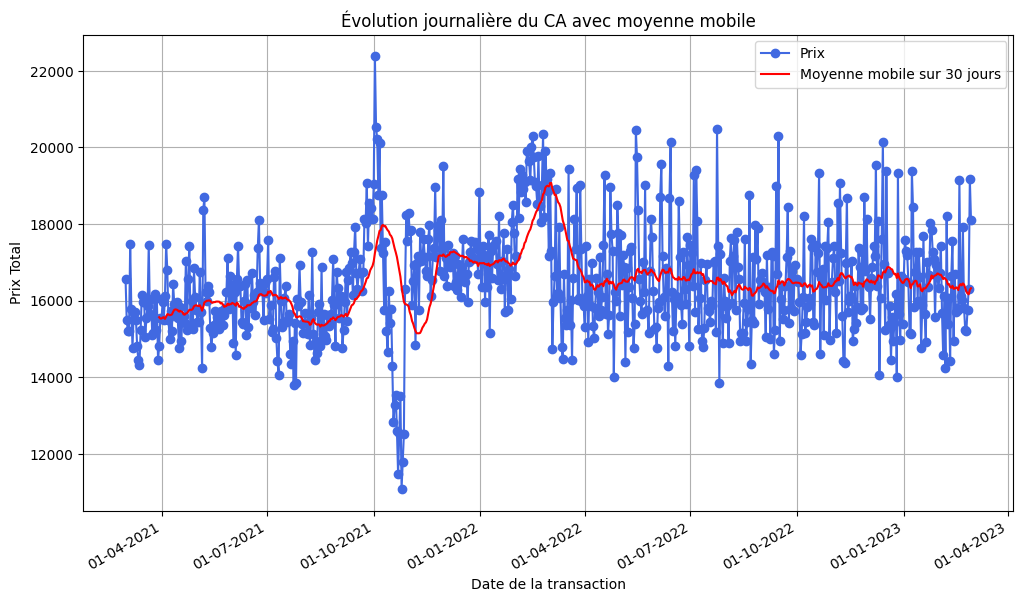

In [134]:
ca_journalier = df_trans_prod.groupby(df_trans_prod['date'].dt.date)['price'].sum().reset_index()
ca_journalier = ca_journalier.sort_values('date')
# Création du graphique en ligne
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
plt.figure(figsize=(12, 7))
plt.plot(ca_journalier['date'], ca_journalier['price'], marker="o", linestyle='-', color='royalblue', label="Prix")
plt.plot(ca_journalier['date'],ca_journalier['price'].rolling(30).mean(),linestyle='-', color='red', label="Moyenne mobile sur 30 jours")
# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()
plt.title('Évolution journalière du CA avec moyenne mobile')
plt.xlabel('Date de la transaction')
plt.ylabel('Prix Total')
plt.grid(True)
plt.show()

In [135]:
ca_mensuel = df_trans_prod.groupby(df_trans_prod['date'].dt.to_period('M'))['price'].sum().reset_index()
ca_mensuel = ca_mensuel.sort_values('date')
#convertir la date
ca_mensuel['date'] = ca_mensuel['date'].dt.to_timestamp()

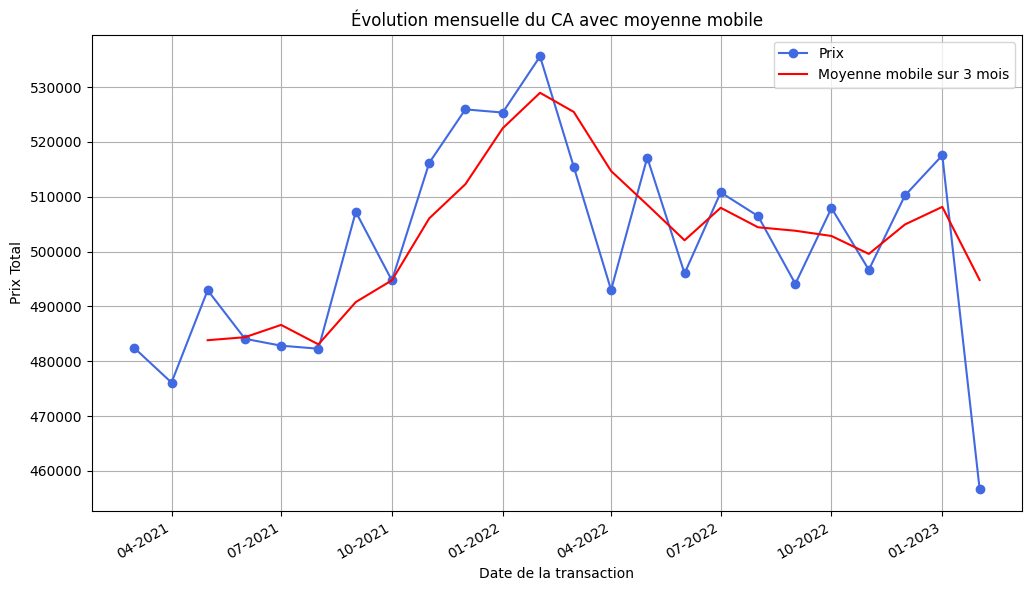

In [136]:
ca_mensuel = df_trans_prod.groupby(df_trans_prod['date'].dt.to_period('M'))['price'].sum().reset_index()
ca_mensuel = ca_mensuel.sort_values('date')
#convertir la date car elle est en periode
ca_mensuel['date'] = ca_mensuel['date'].dt.to_timestamp()

import matplotlib.dates as mdates
# Création du graphique en ligne
plt.figure(figsize=(12, 7))
plt.plot(ca_mensuel['date'], ca_mensuel['price'], marker="o", linestyle='-', color='royalblue', label="Prix")
plt.plot(ca_mensuel['date'],ca_mensuel['price'].rolling(3).mean(),linestyle='-', color='red', label="Moyenne mobile sur 3 mois")
# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()
plt.title('Évolution mensuelle du CA avec moyenne mobile')
plt.xlabel('Date de la transaction')
plt.ylabel('Prix Total')
plt.grid(True)
plt.show()

**2. Évolution dans le temps du CA par categorie**

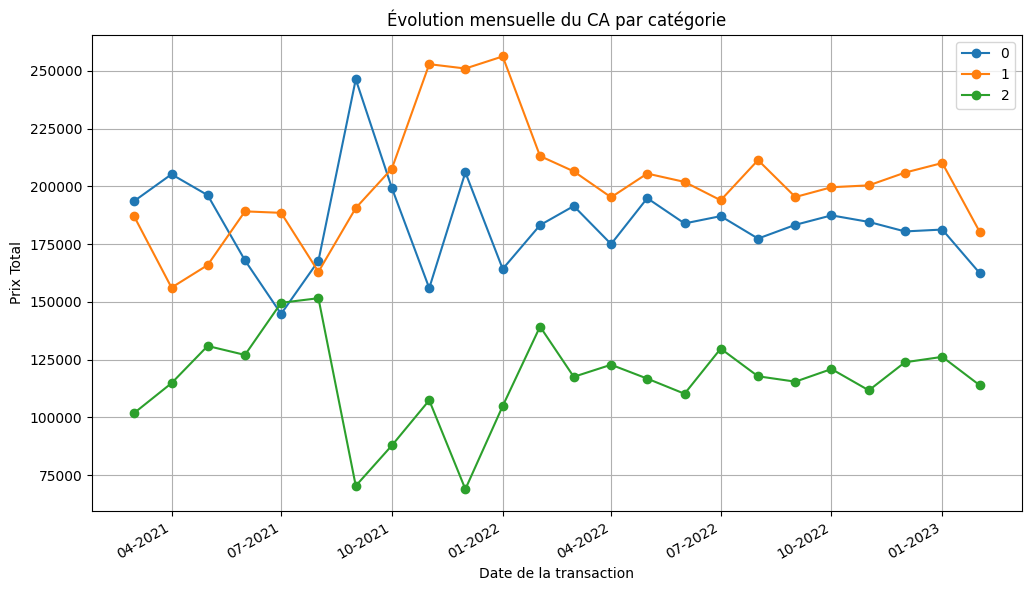

In [137]:
ca_mensuel_categ = df_trans_prod.groupby([df_trans_prod['date'].dt.to_period('M'),'categ'])['price'].sum().reset_index()
ca_mensuel_categ = ca_mensuel_categ.sort_values(['categ', 'date'])
#convertir la date car elle est en periode
ca_mensuel_categ['date'] = ca_mensuel_categ['date'].dt.to_timestamp()
# Création du graphique en ligne
import matplotlib.dates as mdates
plt.figure(figsize=(12, 7))
#tracer toutes les catégories séparément
for cat in ca_mensuel_categ['categ'].unique():
    df_cat = ca_mensuel_categ[ca_mensuel_categ['categ'] == cat]
    plt.plot(df_cat['date'], df_cat['price'], marker='o', linestyle='-', label=cat)

# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()
plt.title('Évolution mensuelle du CA par catégorie')
plt.xlabel('Date de la transaction')
plt.ylabel('Prix Total')
plt.grid(True)
plt.show()

**3. Evolution du nombre de clients par mois**

In [138]:
#fusionner transactions + customers
df_trans_client = df_transactions.merge(df_customers, on='client_id', how='inner')
df_trans_client.head()

,id_prod,date,session_id,client_id,sex,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,59
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,66
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,38
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,37
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,70


In [139]:
nombre_client_mois = df_trans_client.groupby(df_trans_client['date'].dt.to_period('M'))['client_id'].nunique().reset_index()
nombre_client_mois = nombre_client_mois.sort_values('date')
#convertir la date car elle est en periode
nombre_client_mois['date'] = nombre_client_mois['date'].dt.to_timestamp()
nombre_client_mois.columns = ['date', 'nb_clients']
nombre_client_mois.head()

,date,nb_clients
0,2021-03-01,5676
1,2021-04-01,5674
2,2021-05-01,5644
3,2021-06-01,5659
4,2021-07-01,5672


/tmp/ipykernel_3057/882354169.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


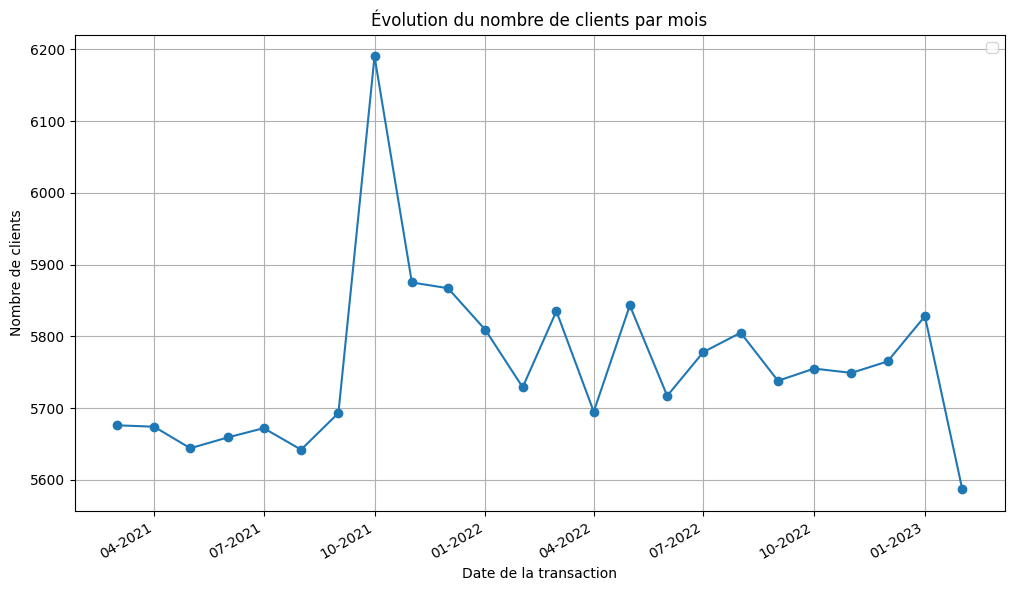

In [140]:
# Création du graphique en ligne
import matplotlib.dates as mdates
plt.figure(figsize=(12, 7))
plt.plot(nombre_client_mois['date'], nombre_client_mois['nb_clients'], marker='o', linestyle='-')

# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()
plt.title('Évolution du nombre de clients par mois')
plt.xlabel('Date de la transaction')
plt.ylabel('Nombre de clients')
plt.grid(True)
plt.show()

**4.  Evolution dans le temps du nombre de transactions**

In [141]:
nombre_transaction_mois = df_transactions.groupby(df_transactions['date'].dt.to_period('M')).size().reset_index()
nombre_transaction_mois = nombre_transaction_mois.sort_values('date')
#convertir la date car elle est en periode
nombre_transaction_mois['date'] = nombre_transaction_mois['date'].dt.to_timestamp()
nombre_transaction_mois.columns = ['date', 'nombre_transaction_mois']
nombre_transaction_mois.head()

,date,nombre_transaction_mois
0,2021-03-01,28601
1,2021-04-01,28443
2,2021-05-01,28285
3,2021-06-01,26850
4,2021-07-01,24738


/tmp/ipykernel_3057/2221851245.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


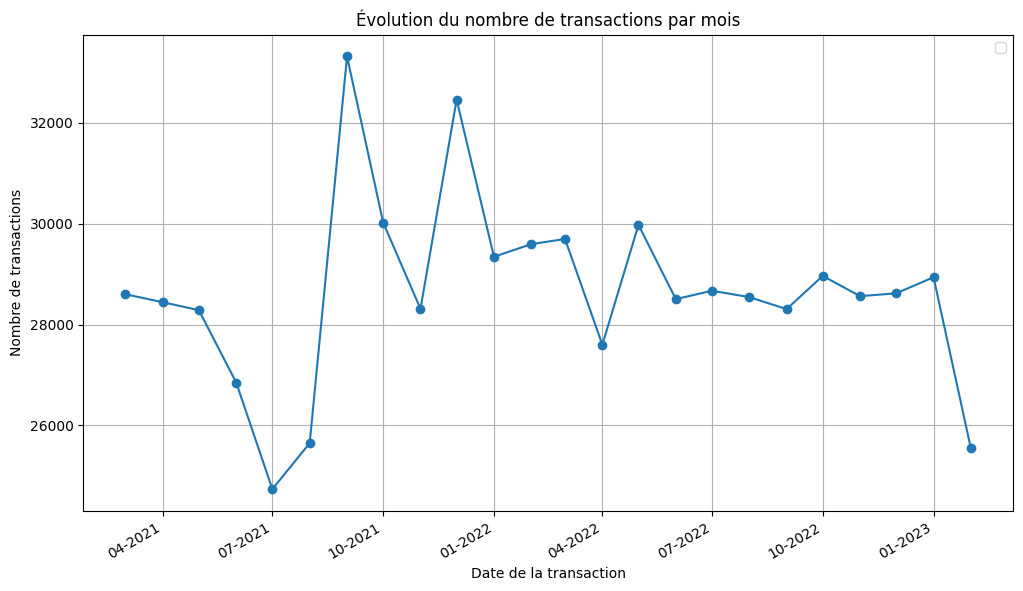

In [142]:
# Création du graphique en ligne
import matplotlib.dates as mdates
plt.figure(figsize=(12, 7))
plt.plot(nombre_transaction_mois['date'], nombre_transaction_mois['nombre_transaction_mois'], marker='o', linestyle='-')

# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()
plt.title('Évolution du nombre de transactions par mois')
plt.xlabel('Date de la transaction')
plt.ylabel('Nombre de transactions')
plt.grid(True)
plt.show()

**5.  Evolution dans le temps du nombre de produits vendus**

In [143]:
nombre_produit_vendu = df_trans_prod.groupby(df_trans_prod['date'].dt.to_period('M'))['id_prod'].count().reset_index()
nombre_produit_vendu = nombre_produit_vendu.sort_values('date')
#convertir la date car elle est en periode
nombre_produit_vendu['date'] = nombre_produit_vendu['date'].dt.to_timestamp()
nombre_produit_vendu.columns = ['date', 'nombre_produit_vendu']
nombre_produit_vendu.head()

,date,nombre_produit_vendu
0,2021-03-01,28601
1,2021-04-01,28443
2,2021-05-01,28285
3,2021-06-01,26850
4,2021-07-01,24738


/tmp/ipykernel_3057/1672884920.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


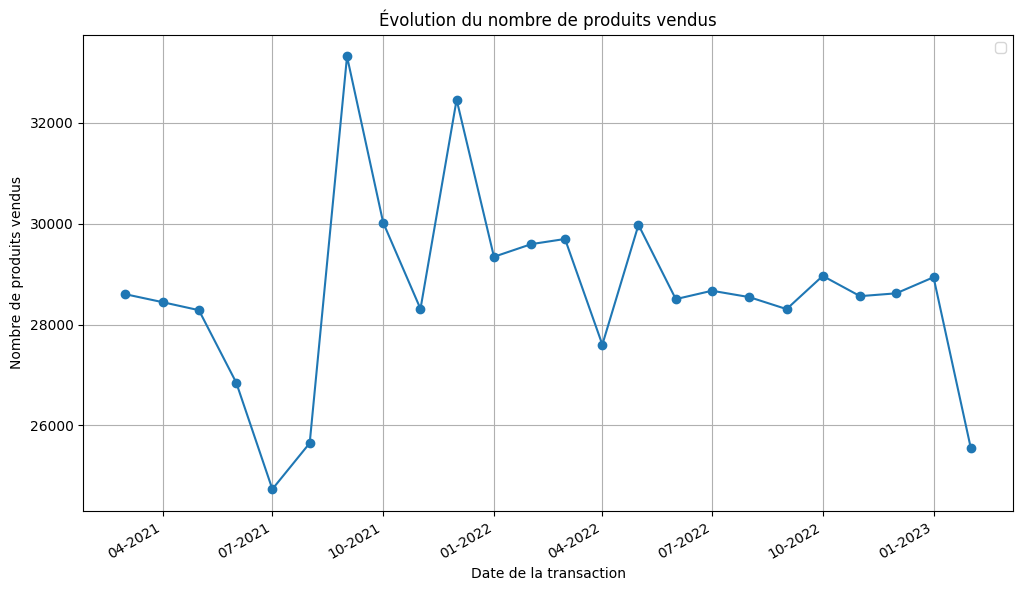

In [144]:
# Création du graphique en ligne
import matplotlib.dates as mdates
plt.figure(figsize=(12, 7))
plt.plot(nombre_produit_vendu['date'], nombre_produit_vendu['nombre_produit_vendu'], marker='o', linestyle='-')

# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()
plt.title('Évolution du nombre de produits vendus')
plt.xlabel('Date de la transaction')
plt.ylabel('Nombre de produits vendus')
plt.grid(True)
plt.show()

**6.1. TOP 10 clients**

In [145]:
ca_par_client = df_trans_prod.groupby('client_id')['price'].sum().reset_index()
ca_par_client = ca_par_client.sort_values(by='price', ascending=False)
top_clients = ca_par_client.head(10)
print(top_clients)

     client_id      price
677     c_1609  326039.89
4388    c_4958  290227.03
6337    c_6714  153918.60
2724    c_3454  114110.57
634     c_1570    5285.82
2513    c_3263    5276.87
1268    c_2140    5260.18
2108    c_2899    5214.05
7006    c_7319    5155.77
7715    c_7959    5135.75


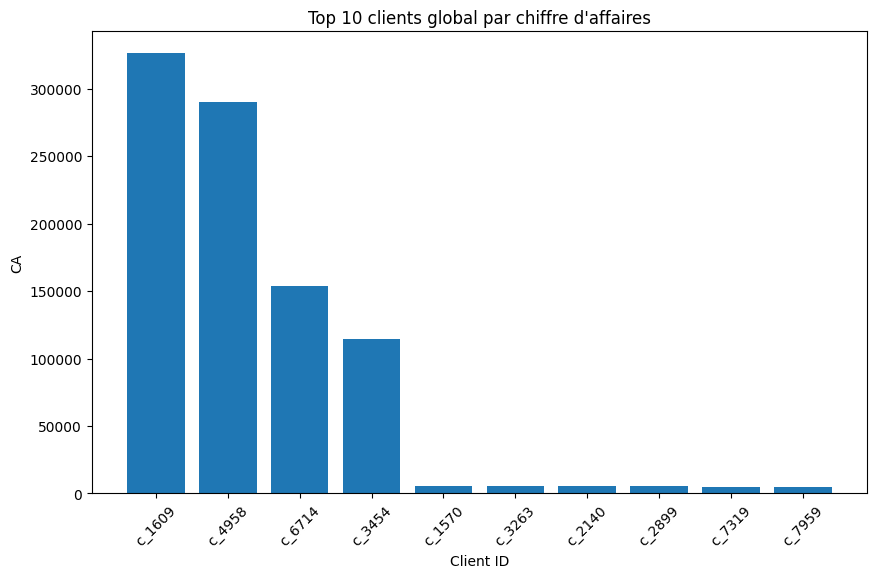

In [146]:
plt.figure(figsize=(10,6))
plt.bar(top_clients['client_id'].astype(str),top_clients['price'])
plt.title("Top 10 clients global par chiffre d'affaires")
plt.xlabel("Client ID")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.show()

In [147]:
#Isoler les clients BtoB
client_BtoB=top_clients.loc[top_clients['price']>10000]
client_BtoB

,client_id,price
677,c_1609,326039.89
4388,c_4958,290227.03
6337,c_6714,153918.60
2724,c_3454,114110.57


In [148]:
client_BtoC=ca_par_client.loc[~ca_par_client['client_id'].isin(client_BtoB['client_id'])]
client_BtoC = client_BtoC.sort_values(by='price', ascending=False)
top_clients_BtoC = client_BtoC.head(10)
print(top_clients_BtoC)

     client_id    price
634     c_1570  5285.82
2513    c_3263  5276.87
1268    c_2140  5260.18
2108    c_2899  5214.05
7006    c_7319  5155.77
7715    c_7959  5135.75
470     c_1422  5131.36
7120    c_7421  5097.18
7791    c_8026  5082.58
1673    c_2505  5059.35


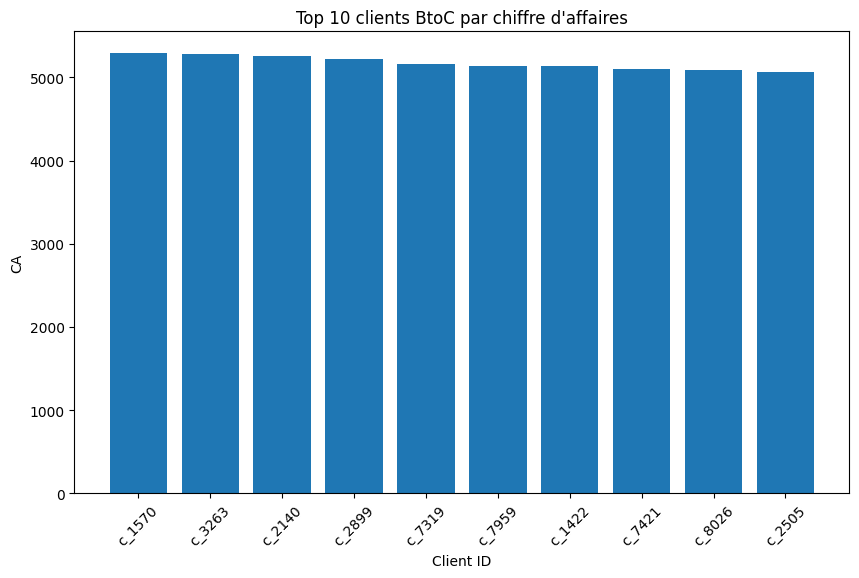

In [149]:
plt.figure(figsize=(10,6))
plt.bar(top_clients_BtoC['client_id'].astype(str),top_clients_BtoC['price'])
plt.title("Top 10 clients BtoC par chiffre d'affaires")
plt.xlabel("Client ID")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.show()

**6.2. 10 Pire clients**

In [150]:
ca_par_client = df_trans_prod.groupby('client_id')['price'].sum().reset_index()
ca_par_client = ca_par_client.sort_values(by='price', ascending=True)
flop_clients = ca_par_client.head(10)
print(flop_clients)

     client_id  price
8151    c_8351   6.31
7918    c_8140   8.30
7889    c_8114   9.98
4044    c_4648  11.20
3855    c_4478  13.36
5589    c_6040  15.72
5453    c_5919  15.98
5354    c_5829  16.07
7798    c_8032  17.64
4408    c_4976  17.89


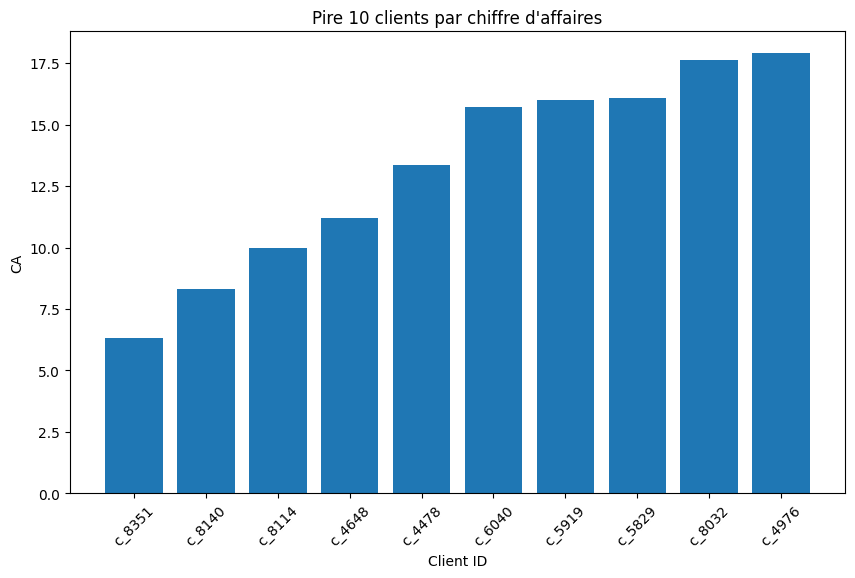

In [151]:
plt.figure(figsize=(10,6))
plt.bar(flop_clients['client_id'].astype(str),flop_clients['price'])
plt.title("Pire 10 clients par chiffre d'affaires")
plt.xlabel("Client ID")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.show()

**7.1. Top 10 produits**

In [152]:
ca_par_produit = df_trans_prod.groupby('id_prod')['price'].sum().reset_index()
ca_par_produit = ca_par_produit.sort_values(by='price', ascending=False)
top_produits = ca_par_produit.head(10)
print(top_produits)

     id_prod     price
3096   2_159  94893.50
3070   2_135  69334.95
3045   2_112  65407.76
3034   2_102  60736.78
3152   2_209  56971.86
2619   1_395  56617.47
2591   1_369  56136.60
3043   2_110  53846.25
2607   1_383  53834.43
2641   1_414  53522.18


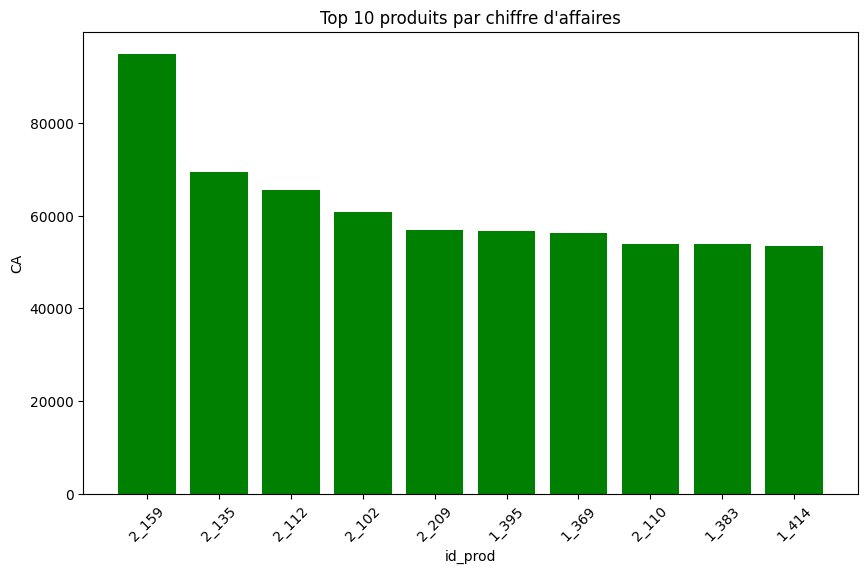

In [153]:
plt.figure(figsize=(10,6))
plt.bar(top_produits['id_prod'].astype(str),top_produits['price'],color='green')
plt.title("Top 10 produits par chiffre d'affaires")
plt.xlabel("id_prod")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.show()

**7.2. Flop 10 produits**

In [154]:
ca_par_produit = df_trans_prod.groupby('id_prod')['price'].sum().reset_index()
ca_par_produit = ca_par_produit.sort_values(by='price', ascending=True)
flop_produits = ca_par_produit.head(10)
print(flop_produits)

     id_prod  price
595   0_1539   0.99
313   0_1284   1.38
719   0_1653   1.98
1784   0_541   1.99
665   0_1601   1.99
2079   0_807   1.99
802   0_1728   2.27
549   0_1498   2.48
2179   0_898   2.54
925   0_1840   2.56


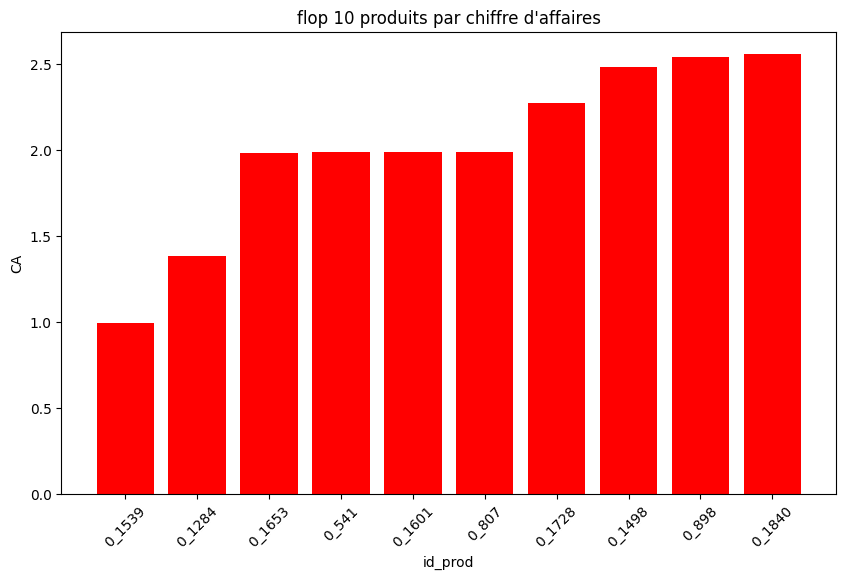

In [155]:
plt.figure(figsize=(10,6))
plt.bar(flop_produits['id_prod'].astype(str),flop_produits['price'],color='red')
plt.title("flop 10 produits par chiffre d'affaires")
plt.xlabel("id_prod")
plt.ylabel("CA")
plt.xticks(rotation=45)
plt.show()

**8.1. Répartition CA par catégorie**





In [156]:
ca_par_categ = df_trans_prod.groupby('categ')['price'].sum().reset_index()
ca_par_categ = ca_par_categ.sort_values(by='price', ascending=True)
print(ca_par_categ)

   categ       price
2      2  2780275.02
0      0  4419730.97
1      1  4827657.11


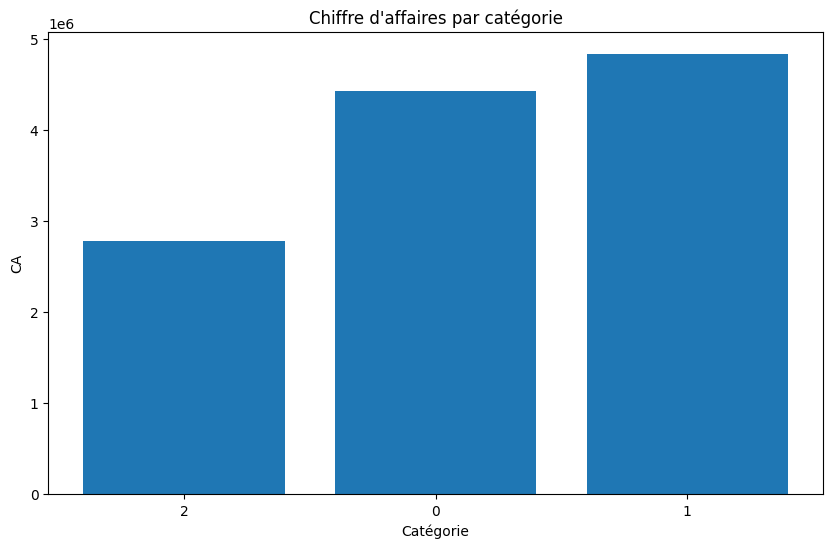

In [157]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(ca_par_categ['categ'].astype(str), ca_par_categ['price'])
plt.title("Chiffre d'affaires par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("CA")
plt.show()

**8.2. Répartition Prix moyen par catégorie**

In [158]:
prix_moy_categ = df_trans_prod.groupby('categ')['price'].mean().reset_index(name=('prix_moyen'))
prix_moy_categ = prix_moy_categ.sort_values(by='prix_moyen', ascending=True)
prix_moy_categ['prix_moyen']=prix_moy_categ['prix_moyen'].round(2)
print(prix_moy_categ)

   categ  prix_moyen
0      0       10.64
1      1       20.49
2      2       76.21


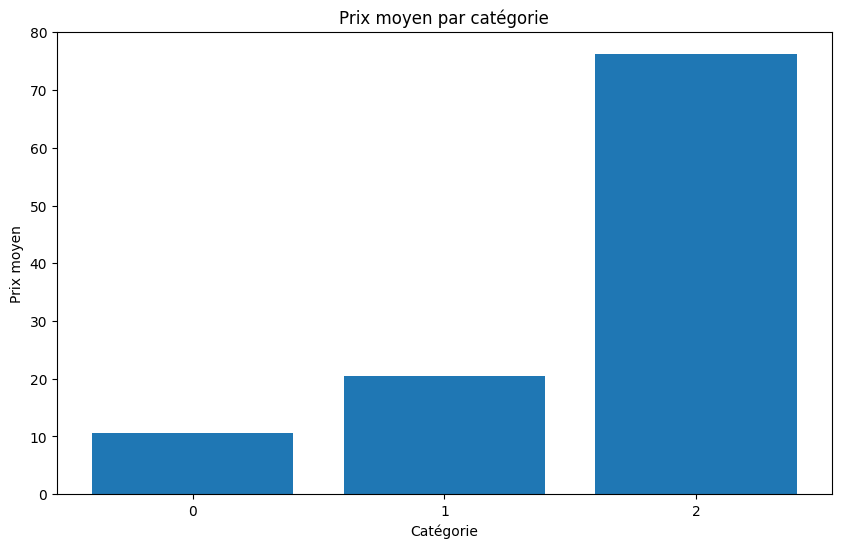

In [159]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(prix_moy_categ['categ'].astype(str), prix_moy_categ['prix_moyen'])
plt.title("Prix moyen par catégorie")
plt.xlabel("Catégorie")
plt.ylabel("Prix moyen")
plt.show()

**8.3. Répartition des clients par age**

In [160]:
df_customers['age'].describe()

,age
count,8621.000000
mean,47.724394
std,16.917958
min,22.000000
25%,34.000000
50%,47.000000
75%,60.000000
max,97.000000


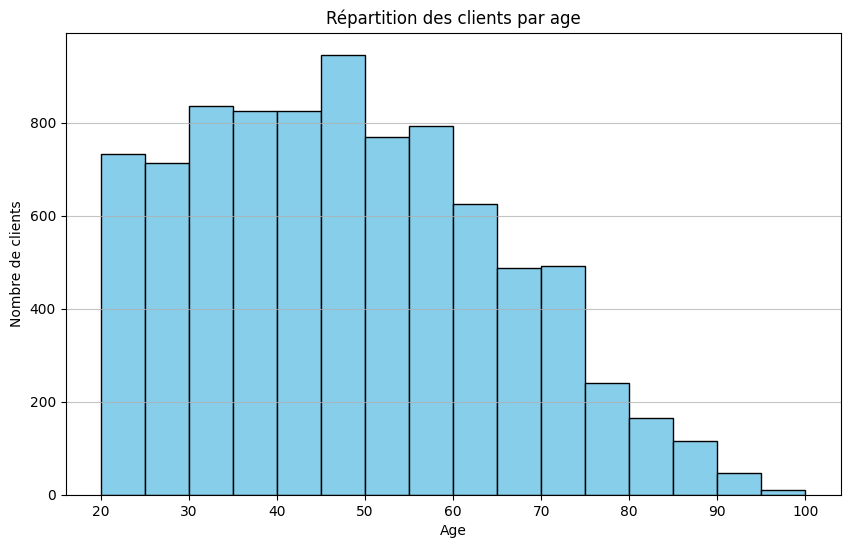

In [161]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
bins = np.arange(20, 101, 5)  # 20, 30, 40, ..., 100
plt.hist(df_customers['age'], bins=bins, color='skyblue', edgecolor='black')
plt.title('Répartition des clients par age')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')
plt.grid(axis='y', alpha=0.75)
plt.show()

**8.4. Répartition du Panier moyen par tranche d ages**

In [162]:
df_trans_prod_client=df_trans_prod.merge(df_customers,how='inner',on='client_id')
panier_session = df_trans_prod_client.groupby(['session_id','age'])['price'].sum().reset_index(name='montant_panier')
panier_session.head()

,session_id,age,montant_panier
0,s_1,59,11.99
1,s_10,56,26.99
2,s_100,48,33.72
3,s_1000,37,39.22
4,s_10000,37,41.49


In [163]:
bins = np.arange(20, 101, 5)  # 20, 30, 40, ..., 100
panier_moyen_age = panier_session.groupby(pd.cut(panier_session['age'], bins=bins))['montant_panier'].mean().reset_index(name='panier_moyen_age')
panier_moyen_age.head()

/tmp/ipykernel_3057/3975849615.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  panier_moyen_age = panier_session.groupby(pd.cut(panier_session['age'], bins=bins))['montant_panier'].mean().reset_index(name='panier_moyen_age')


,age,panier_moyen_age
0,"(20, 25]",70.506774
1,"(25, 30]",71.830638
2,"(30, 35]",55.937869
3,"(35, 40]",32.064076
4,"(40, 45]",31.990513


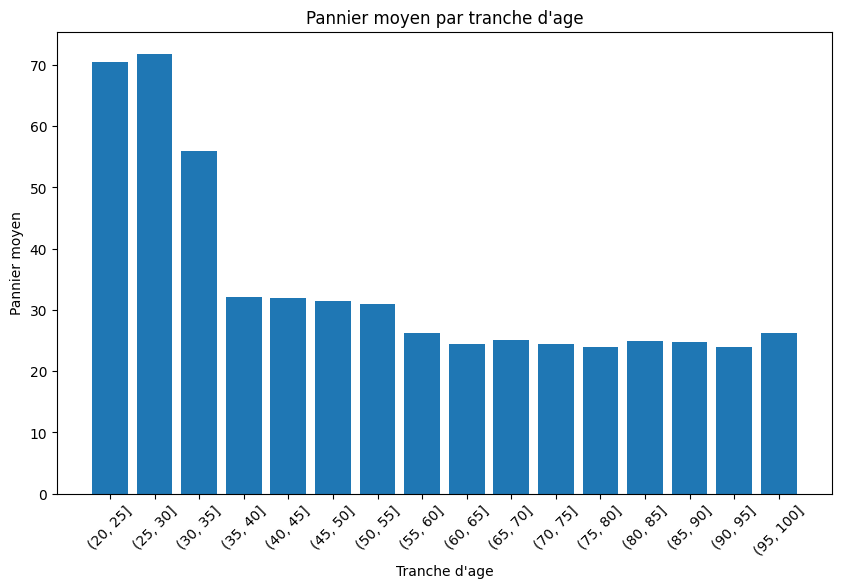

In [164]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(panier_moyen_age['age'].astype(str), panier_moyen_age['panier_moyen_age'])
plt.title("Pannier moyen par tranche d'age")
plt.xlabel("Tranche d'age")
plt.xticks(rotation=45)
plt.ylabel("Pannier moyen")
plt.show()

In [165]:
ca_par_client

,client_id,price
8151,c_8351,6.31
7918,c_8140,8.30
7889,c_8114,9.98
4044,c_4648,11.20
3855,c_4478,13.36
...,...,...
634,c_1570,5285.82
2724,c_3454,114110.57
6337,c_6714,153918.60
4388,c_4958,290227.03


In [166]:
ca_par_client

,client_id,price
8151,c_8351,6.31
7918,c_8140,8.30
7889,c_8114,9.98
4044,c_4648,11.20
3855,c_4478,13.36
...,...,...
634,c_1570,5285.82
2724,c_3454,114110.57
6337,c_6714,153918.60
4388,c_4958,290227.03


**9.Courbe de lorenz**

**9.1.Courbe de lorenz du CA par client**



In [167]:
ca_par_client

,client_id,price
8151,c_8351,6.31
7918,c_8140,8.30
7889,c_8114,9.98
4044,c_4648,11.20
3855,c_4478,13.36
...,...,...
634,c_1570,5285.82
2724,c_3454,114110.57
6337,c_6714,153918.60
4388,c_4958,290227.03


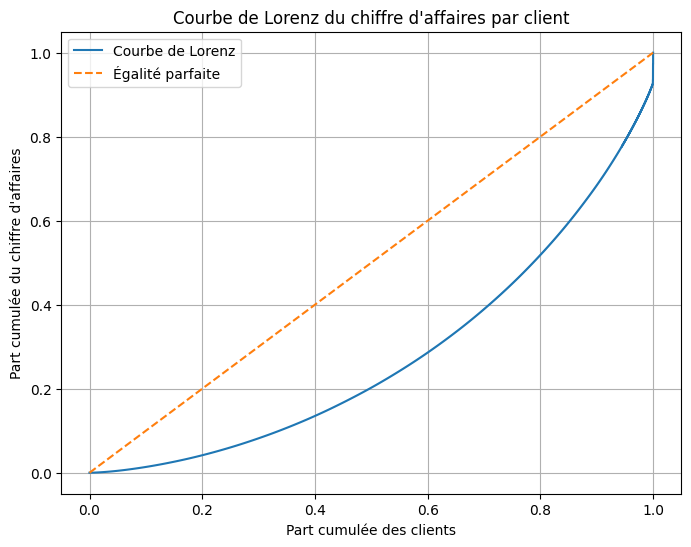

In [168]:
#Courbe de lorenz du CA par client global
import numpy as np
# 2. Nombre de clients
n = len(ca_par_client)
# 3. Cumul du CA / CA total
lorenz = np.cumsum(ca_par_client['price']) / ca_total
# 4. Ajouter le point de départ (0,0)
lorenz = np.append([0],lorenz) # La courbe de Lorenz commence à 0
# 5. Axe des x = part cumulée des clients
xaxis = np.linspace(0-1/n,1+1/n,len(lorenz)) #Il y a un segment de taille n pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/n, et le dernier termine à 1+1/n.
# 6. Tracé
plt.figure(figsize=(8, 6))
plt.plot(xaxis,lorenz,drawstyle='steps-post',label='Courbe de Lorenz')
plt.plot([0,1], [0,1], '--', label='Égalité parfaite') #tracer la bisséctrice
plt.title("Courbe de Lorenz du chiffre d'affaires par client")
plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du chiffre d'affaires")
plt.legend()
plt.grid(True)
plt.show()

In [169]:
# Gini = 0 : égalité parfaite /autour de 0,2 : faible inégalité /autour de 0,4 : inégalité notable /au-dessus de 0,5 : forte concentration/Gini = 1 : inégalité totale
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/n # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S
gini

np.float64(0.44189587995615665)

In [170]:
client_BtoC

,client_id,price
634,c_1570,5285.82
2513,c_3263,5276.87
1268,c_2140,5260.18
2108,c_2899,5214.05
7006,c_7319,5155.77
...,...,...
3855,c_4478,13.36
4044,c_4648,11.20
7889,c_8114,9.98
7918,c_8140,8.30


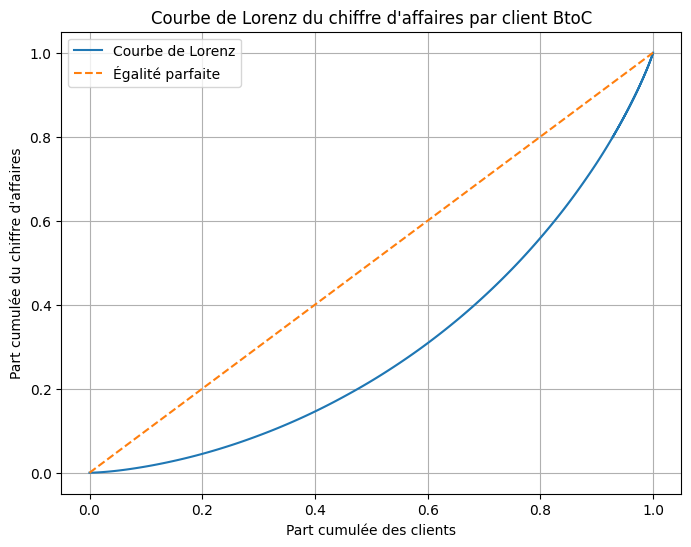

In [171]:
#Courbe de lorenz du CA par client BtoC
client_BtoC = client_BtoC.sort_values(by='price', ascending=True)
import numpy as np
# 2. Nombre de clients
n = len(client_BtoC)
# 3. Cumul du CA / CA total
lorenz = np.cumsum(client_BtoC['price']) / client_BtoC['price'].sum()
# 4. Ajouter le point de départ (0,0)
lorenz = np.append([0],lorenz) # La courbe de Lorenz commence à 0
# 5. Axe des x = part cumulée des clients
xaxis = np.linspace(0-1/n,1+1/n,len(lorenz)) #Il y a un segment de taille n pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/n, et le dernier termine à 1+1/n.
# 6. Tracé
plt.figure(figsize=(8, 6))
plt.plot(xaxis,lorenz,drawstyle='steps-post',label='Courbe de Lorenz')
plt.plot([0,1], [0,1], '--', label='Égalité parfaite') #tracer la bisséctrice
plt.title("Courbe de Lorenz du chiffre d'affaires par client BtoC")
plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du chiffre d'affaires")
plt.legend()
plt.grid(True)
plt.show()

In [172]:
# Gini = 0 : égalité parfaite /autour de 0,2 : faible inégalité /autour de 0,4 : inégalité notable /au-dessus de 0,5 : forte concentration/Gini = 1 : inégalité totale
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/n # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S
gini

np.float64(0.39828603507456617)

9.2.Courbe de Lorenz du nombre d’achats par client

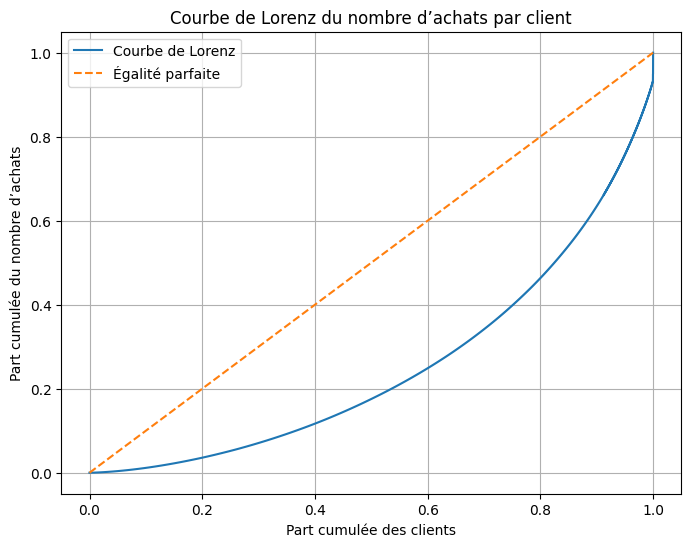

In [173]:
# 1. nbre d'achat par client
nb_achats_client = df_trans_prod.groupby('client_id').size().sort_values().reset_index(name='nb_achats_client')
# 2. Nombre de clients
n = len(nb_achats_client)
# 3. Total du nombre d'achats
nb_achats_total = nb_achats_client['nb_achats_client'].sum()
# 4. Part cumulée du nombre d'achats
lorenz = np.cumsum(nb_achats_client['nb_achats_client']) / nb_achats_total
# 5. Ajouter le point de départ (0,0)
lorenz = np.append([0],lorenz) # La courbe de Lorenz commence à 0
# 6. Axe des x = part cumulée des clients
xaxis = np.linspace(0-1/n,1+1/n,len(lorenz)) #Il y a un segment de taille n pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/n, et le dernier termine à 1+1/n.
# 7. Tracé
plt.figure(figsize=(8, 6))
plt.plot(xaxis,lorenz,drawstyle='steps-post',label='Courbe de Lorenz')
plt.plot([0,1], [0,1], '--', label='Égalité parfaite') #tracer la bisséctrice
plt.title("Courbe de Lorenz du nombre d’achats par client")
plt.xlabel("Part cumulée des clients")
plt.ylabel("Part cumulée du nombre d’achats")
plt.legend()
plt.grid(True)
plt.show()

In [174]:
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/n # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S
gini

np.float64(0.49385560636290904)

**9.3.Courbe de Lorenz du CA par produit**

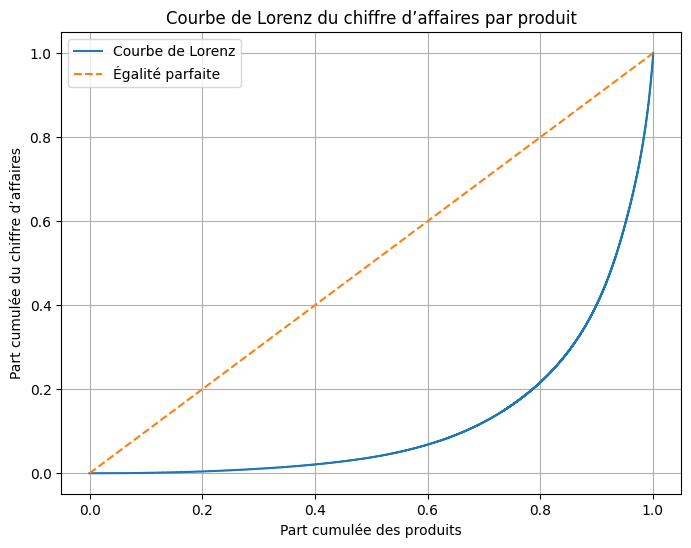

In [175]:
ca_produit = df_trans_prod.groupby('id_prod')['price'].sum().sort_values().reset_index(name='ca_produit')
# 2. Nombre de produits
n = len(ca_produit)
# 3. Part cumulée du nombre d'achats
lorenz = np.cumsum(ca_produit['ca_produit']) / ca_total
# 4. Ajouter le point de départ (0,0)
lorenz = np.append([0],lorenz) # La courbe de Lorenz commence à 0
# 5. Axe des x = part cumulée des clients
xaxis = np.linspace(0-1/n,1+1/n,len(lorenz)) #Il y a un segment de taille n pour chaque individu, plus 1 segment supplémentaire d'ordonnée 0. Le premier segment commence à 0-1/n, et le dernier termine à 1+1/n.
# 6. Tracé
plt.figure(figsize=(8, 6))
plt.plot(xaxis,lorenz,drawstyle='steps-post',label='Courbe de Lorenz')
plt.plot([0,1], [0,1], '--', label='Égalité parfaite') #tracer la bisséctrice
plt.title("Courbe de Lorenz du chiffre d’affaires par produit")
plt.xlabel("Part cumulée des produits")
plt.ylabel("Part cumulée du chiffre d’affaires")
plt.legend()
plt.grid(True)
plt.show()

In [176]:
AUC = (lorenz.sum() -lorenz[-1]/2 -lorenz[0]/2)/n # Surface sous la courbe de Lorenz. Le premier segment (lorenz[0]) est à moitié en dessous de 0, on le coupe donc en 2, on fait de même pour le dernier segment lorenz[-1] qui est à moitié au dessus de 1.
S = 0.5 - AUC # surface entre la première bissectrice et le courbe de Lorenz
gini = 2*S
gini

np.float64(0.7439971111384899)



---



**10.1. Corrélation entre le genre et les catégories de livres achetés (2 variables qualitatives)**

In [177]:
# garder seulement les transactions des clients BtoC
df_btoc = df_trans_prod_client[df_trans_prod_client['client_id'].isin(client_BtoC['client_id'])].copy()
# afficher le tableau de contingence
X = "sex"
Y = "categ"
cont = df_btoc[[X,Y]].pivot_table(index=X,columns=Y,aggfunc=len)
# autres commande du tableau : cont = pd.crosstab(df_trans_prod_client['sex'], df_trans_prod_client['categ'], margins=True)
cont

categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


<Figure size 1000x600 with 0 Axes>

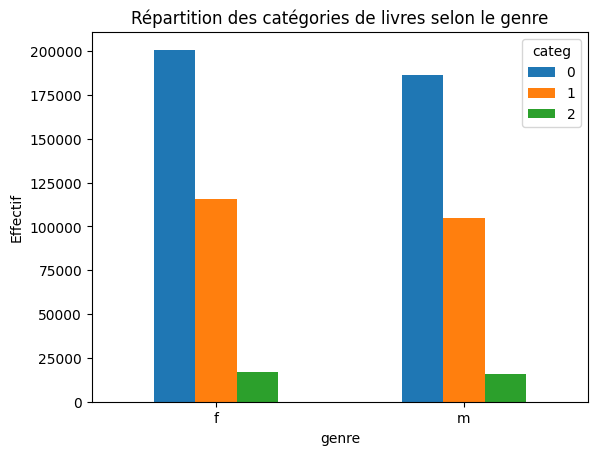

In [178]:
#Tracer le graphique
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
cont.plot(kind='bar')
plt.title("Répartition des catégories de livres selon le genre")
plt.xlabel("genre")
plt.ylabel("Effectif")
plt.xticks(rotation=0)
plt.show()

Hypothèses du test

H0 : le sexe et la catégorie achetée sont indépendants

H1 : le sexe et la catégorie achetée sont dépendants / associés

In [179]:
# Calculer le test du Chi-2
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(cont)

print(f"Statistique Chi-2: {chi2_stat}")
print(f"Valeur p: {p_value}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)

Statistique Chi-2: 22.66856665178056
Valeur p: 1.1955928116587024e-05
Degrés de liberté: 2
Fréquences attendues:
[[201574.89662481 114822.13191434  17096.97146086]
 [185706.10337519 105782.86808566  15751.02853914]]


**10.2.Corrélation entre l’âge et le montant total des achats (2 variables quantitatives)**

In [180]:
montant_client=df_trans_prod_client.groupby('age')['price'].sum().reset_index(name='montant_total')
montant_client.head()

,age,montant_total
0,22,616418.15
1,23,180680.89
2,24,186791.83
3,25,181233.57
4,26,167388.08


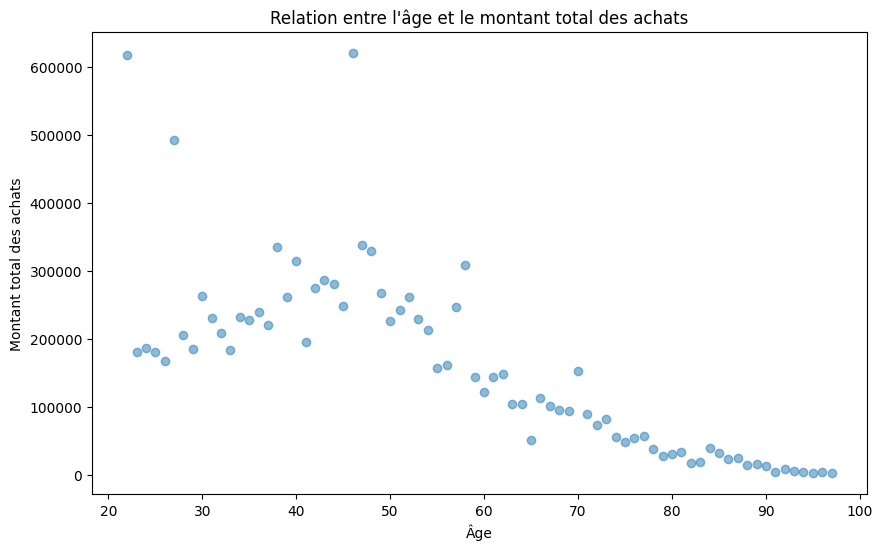

In [181]:
#Tracer le graphique en nuage de points
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(montant_client['age'], montant_client['montant_total'],alpha=0.5)
#plt.yscale('log')
plt.title("Relation entre l'âge et le montant total des achats")
plt.xlabel("Âge")
plt.ylabel("Montant total des achats")
plt.show()

Hypothèses du test de Spearman

H0 : il n’existe pas de corrélation entre l’âge et le montant total des achats.

H1 : il existe une corrélation entre l’âge et le montant total des achats.

In [182]:
#Testez la corrélation avec Spearman
# Calculer le coefficient de corrélation de Spearman et la valeur p
from scipy.stats import spearmanr
spearman_corr, spearman_p_value = spearmanr(montant_client['age'], montant_client['montant_total'])

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

Coefficient de corrélation de Spearman: -0.8583732057416268
Valeur p: 3.805937971547995e-23


___________________________________________________________________________________________________

In [183]:
#Corrélation entre l’âge et le montant total des achats sur les client BtoC (2 variables quantitatives)
# montant total des achats par âge
montant_client_btoc = (df_btoc.groupby('age')['price'].sum().reset_index(name='montant_total'))
montant_client_btoc.head()

,age,montant_total
0,22,616418.15
1,23,180680.89
2,24,186791.83
3,25,181233.57
4,26,167388.08


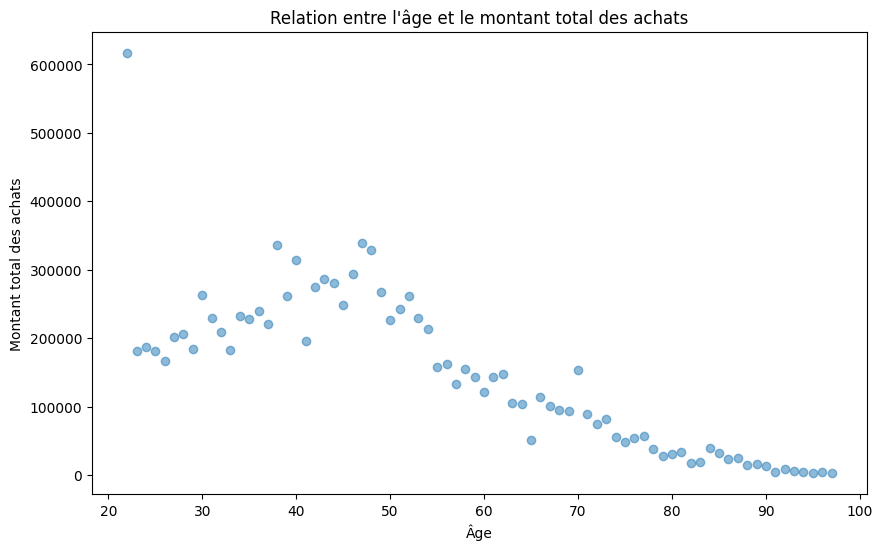

In [184]:
#Tracer le graphique en nuage de points
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(montant_client_btoc['age'], montant_client_btoc['montant_total'],alpha=0.5)
#plt.yscale('log')
plt.title("Relation entre l'âge et le montant total des achats")
plt.xlabel("Âge")
plt.ylabel("Montant total des achats")
plt.show()

In [185]:
#Testez la corrélation avec Spearman
# Calculer le coefficient de corrélation de Spearman et la valeur p
from scipy.stats import spearmanr
spearman_corr, spearman_p_value = spearmanr(montant_client_btoc['age'], montant_client_btoc['montant_total'])
print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

Coefficient de corrélation de Spearman: -0.8744497607655503
Valeur p: 5.956077505475151e-25


**10.3. Corrélation entre l’âge et la fréquence d’achat (2 variables quantitatives) **

In [186]:
nb_achats=df_trans_client.groupby('age')['session_id'].nunique().reset_index(name='nb_achats')
nb_achats.head()

,age,nb_achats
0,22,8756
1,23,2615
2,24,2666
3,25,2488
4,26,2476


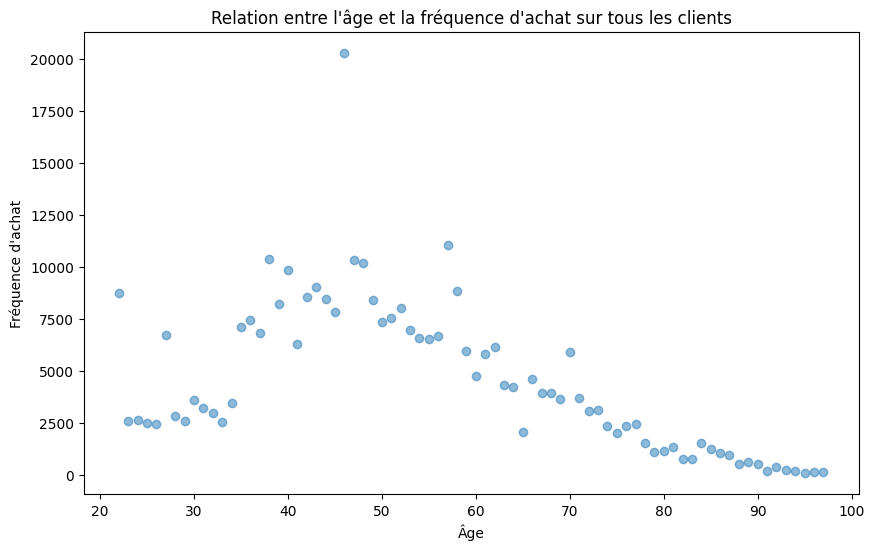

In [187]:
#Tracer le graohique en nuage de points
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(nb_achats['age'], nb_achats['nb_achats'],alpha=0.5)
#plt.yscale('log')
plt.title("Relation entre l'âge et la fréquence d'achat sur tous les clients")
plt.xlabel("Âge")
plt.ylabel("Fréquence d'achat")
plt.show()

Hypothèses du test de Spearman

H0 : il n’existe pas de corrélation entre l’âge et la fréquence d'achats.

H1 : il existe une corrélation entre l’âge la fréquence d'achats.

In [188]:
#Testez la corrélations avec Spearman
# Calculer le coefficient de corrélation de Spearman et la valeur p
from scipy.stats import spearmanr
spearman_corr, spearman_p_value = spearmanr(nb_achats['age'], nb_achats['nb_achats'])
print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

Coefficient de corrélation de Spearman: -0.6641968557758032
Valeur p: 6.113685795772159e-11


--------------------------------------------------------------------------------------------------------

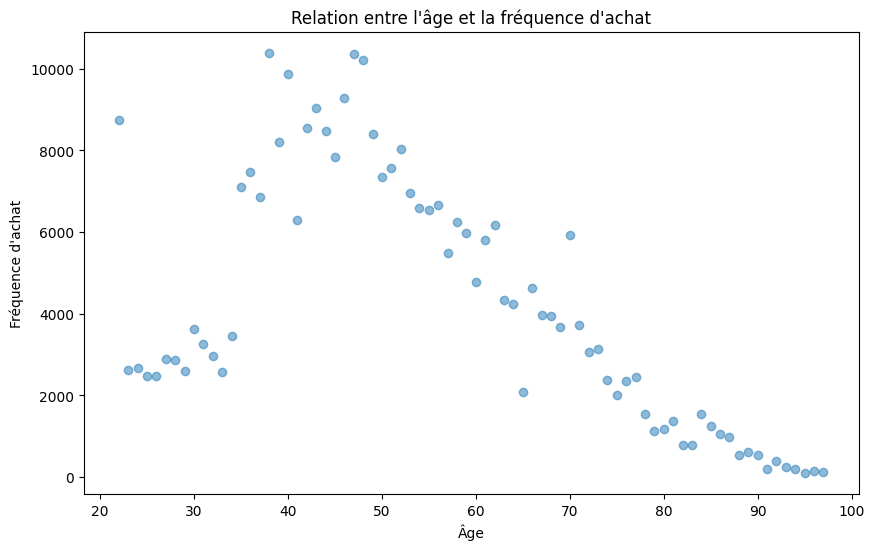

Coefficient de corrélation de Spearman: -0.6593848257006152
Valeur p: 9.36237939303452e-11


In [189]:
#Corrélation entre l’âge des client BtoC et la fréquence d’achat (2 variables quantitatives)
nb_achats_BtoC=df_btoc.groupby('age')['session_id'].nunique().reset_index(name='nb_achats')
#Tracer le graohique en nuage de points
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(nb_achats_BtoC['age'], nb_achats_BtoC['nb_achats'],alpha=0.5)
#plt.yscale('log')
plt.title("Relation entre l'âge et la fréquence d'achat")
plt.xlabel("Âge")
plt.ylabel("Fréquence d'achat")
plt.show()
#Testez la corrélations avec Spearman
# Calculer le coefficient de corrélation de Spearman et la valeur p
from scipy.stats import spearmanr
spearman_corr, spearman_p_value = spearmanr(nb_achats_BtoC['age'], nb_achats_BtoC['nb_achats'])
print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

**10.4. Corrélation entre l’âge et la taille du panier moyen**

In [190]:
panier_session = df_btoc.groupby(['session_id','age'])['price'].sum().reset_index(name='montant_panier')
panier_session.head()

,session_id,age,montant_panier
0,s_1,59,11.99
1,s_10,56,26.99
2,s_100,48,33.72
3,s_1000,37,39.22
4,s_10000,37,41.49


In [191]:
panier_moyen_age = panier_session.groupby('age')['montant_panier'].mean().reset_index(name='panier_moyen_age')
panier_moyen_age.head()

,age,panier_moyen_age
0,22,70.399515
1,23,69.094031
2,24,70.064452
3,25,72.843075
4,26,67.604233


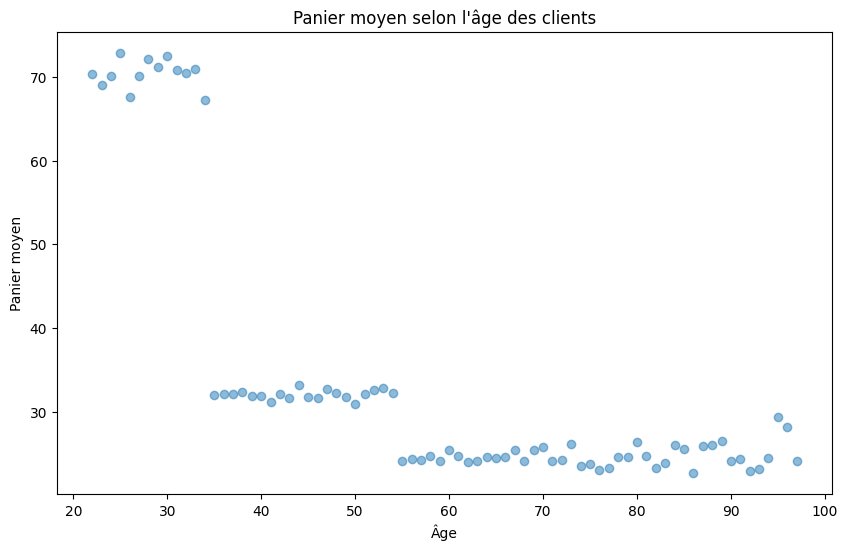

In [192]:
#Tracer le graphique en nuage de points
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(panier_moyen_age['age'], panier_moyen_age['panier_moyen_age'],alpha=0.5)
plt.title("Panier moyen selon l'âge des clients")
plt.xlabel("Âge")
plt.ylabel("Panier moyen")
plt.show()

Hypothèses du test de Spearman

H0 : il n’existe pas de corrélation entre l’âge et la taille du panier moyen

H1 : il existe une corrélation entre l’âge et la taille du panier moyen

In [193]:
#Testez la corrélations avec Spearman
# Calculer le coefficient de corrélation de Spearman et la valeur p
from scipy.stats import spearmanr
spearman_corr, spearman_p_value = spearmanr(panier_moyen_age['age'], panier_moyen_age['panier_moyen_age'])
print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

Coefficient de corrélation de Spearman: -0.7824196855775802
Valeur p: 7.049554602185417e-17


------------------------------------------------------------------

**10.5. Corrélation entre l’âge  et la catégorie des livres achetés (1 variable quantitative et 1 variable qualitative**

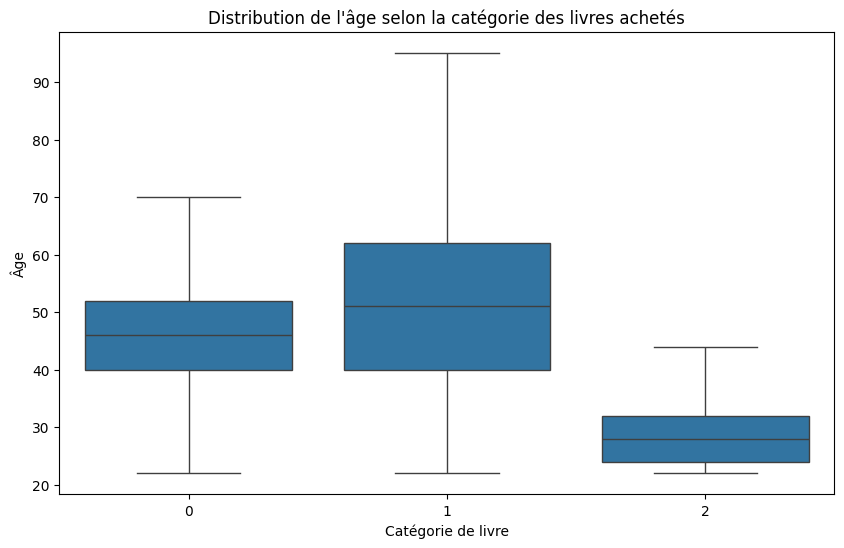

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df_btoc, x='categ', y='age', showfliers=False)
plt.title("Distribution de l'âge selon la catégorie des livres achetés")
plt.xlabel("Catégorie de livre")
plt.ylabel("Âge")
plt.show()

Test de normalité

H0 : les données suivent une distribution normale

H1 : les données ne suivent pas une distribution normale

Catégorie affichée : 0


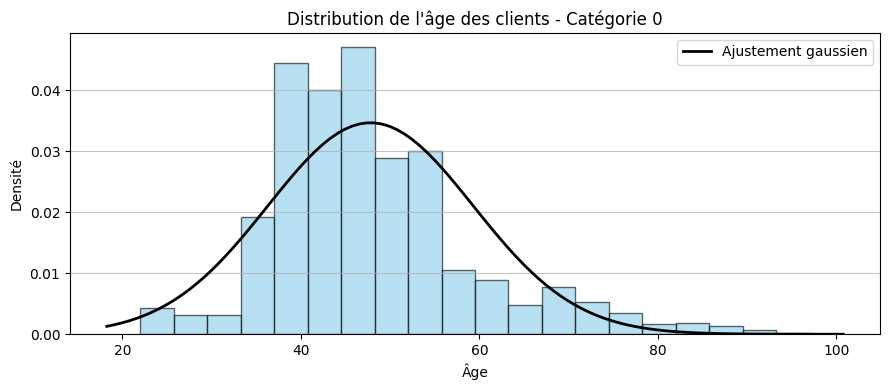

Catégorie affichée : 1


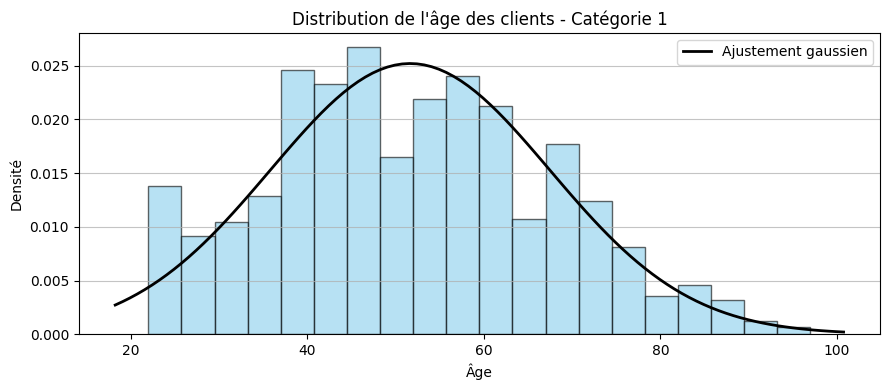

Catégorie affichée : 2


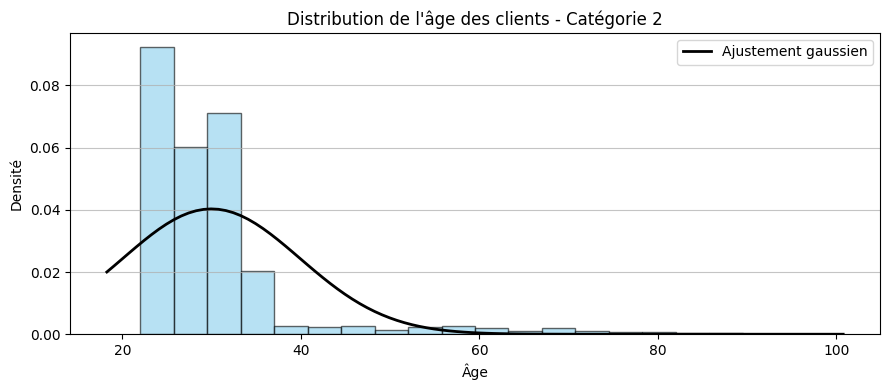

In [195]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

for categorie in sorted(df_btoc['categ'].dropna().unique()):
    print("Catégorie affichée :", categorie)

    age_categorie = df_btoc[
        df_btoc['categ'] == categorie
    ]['age'].dropna()

    plt.figure(figsize=(9, 4))

    plt.hist(
        age_categorie,
        bins=20,
        density=True,
        color='skyblue',
        edgecolor='black',
        alpha=0.6
    )

    mu, std = norm.fit(age_categorie)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    plt.plot(x, p, 'k', linewidth=2, label='Ajustement gaussien')

    plt.title(f"Distribution de l'âge des clients - Catégorie {categorie}")
    plt.xlabel("Âge")
    plt.ylabel("Densité")
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

In [196]:
from scipy.stats import shapiro

alpha = 0.05

for categorie in sorted(df_btoc['categ'].unique()):

    age_categorie = df_btoc[
        df_btoc['categ'] == categorie
    ]['age'].dropna()

    # Shapiro est sensible aux grands échantillons
    if len(age_categorie) > 5000:
        age_test = age_categorie.sample(5000, random_state=42)
    else:
        age_test = age_categorie

    stat, p_value = shapiro(age_test)

    print("Catégorie :", categorie)
    print("Taille de l'échantillon :", len(age_test))
    print(f"Statistique du test de Shapiro-Wilk : {stat}")
    print(f"Valeur p : {p_value}")

    if p_value > alpha:
        print("Les données suivent une distribution normale : on ne rejette pas H0")
    else:
        print("Les données ne suivent pas une distribution normale : on rejette H0")

    print("-" * 50)

Catégorie : 0
Taille de l'échantillon : 5000
Statistique du test de Shapiro-Wilk : 0.9332318304213082
Valeur p : 1.176093897162146e-42
Les données ne suivent pas une distribution normale : on rejette H0
--------------------------------------------------
Catégorie : 1
Taille de l'échantillon : 5000
Statistique du test de Shapiro-Wilk : 0.9882621670580967
Valeur p : 5.554692084174592e-20
Les données ne suivent pas une distribution normale : on rejette H0
--------------------------------------------------
Catégorie : 2
Taille de l'échantillon : 5000
Statistique du test de Shapiro-Wilk : 0.6823690142982062
Valeur p : 1.2040579051068622e-70
Les données ne suivent pas une distribution normale : on rejette H0
--------------------------------------------------


Hypothèses de Kruskal-Wallis

H0 : la distribution de l’âge est la même dans toutes les catégories de livres.

H1 : au moins une catégorie présente une distribution d’âge différente.

In [197]:
# Calculer le test de Kruskal-Wallis
from scipy.stats import kruskal
# âges par catégorie
groupe_0 = df_trans_prod_client[df_trans_prod_client['categ'] == 0]['age']
groupe_1 = df_trans_prod_client[df_trans_prod_client['categ'] == 1]['age']
groupe_2 = df_trans_prod_client[df_trans_prod_client['categ'] == 2]['age']
# test de Kruskal-Wallis
f_stat, p_value = kruskal(groupe_0, groupe_1, groupe_2)

print(f"Statistique de Kruskal-Wallis: {f_stat}")
print(f"Valeur p: {p_value}")

Statistique de Kruskal-Wallis: 78458.43837285662
Valeur p: 0.0
